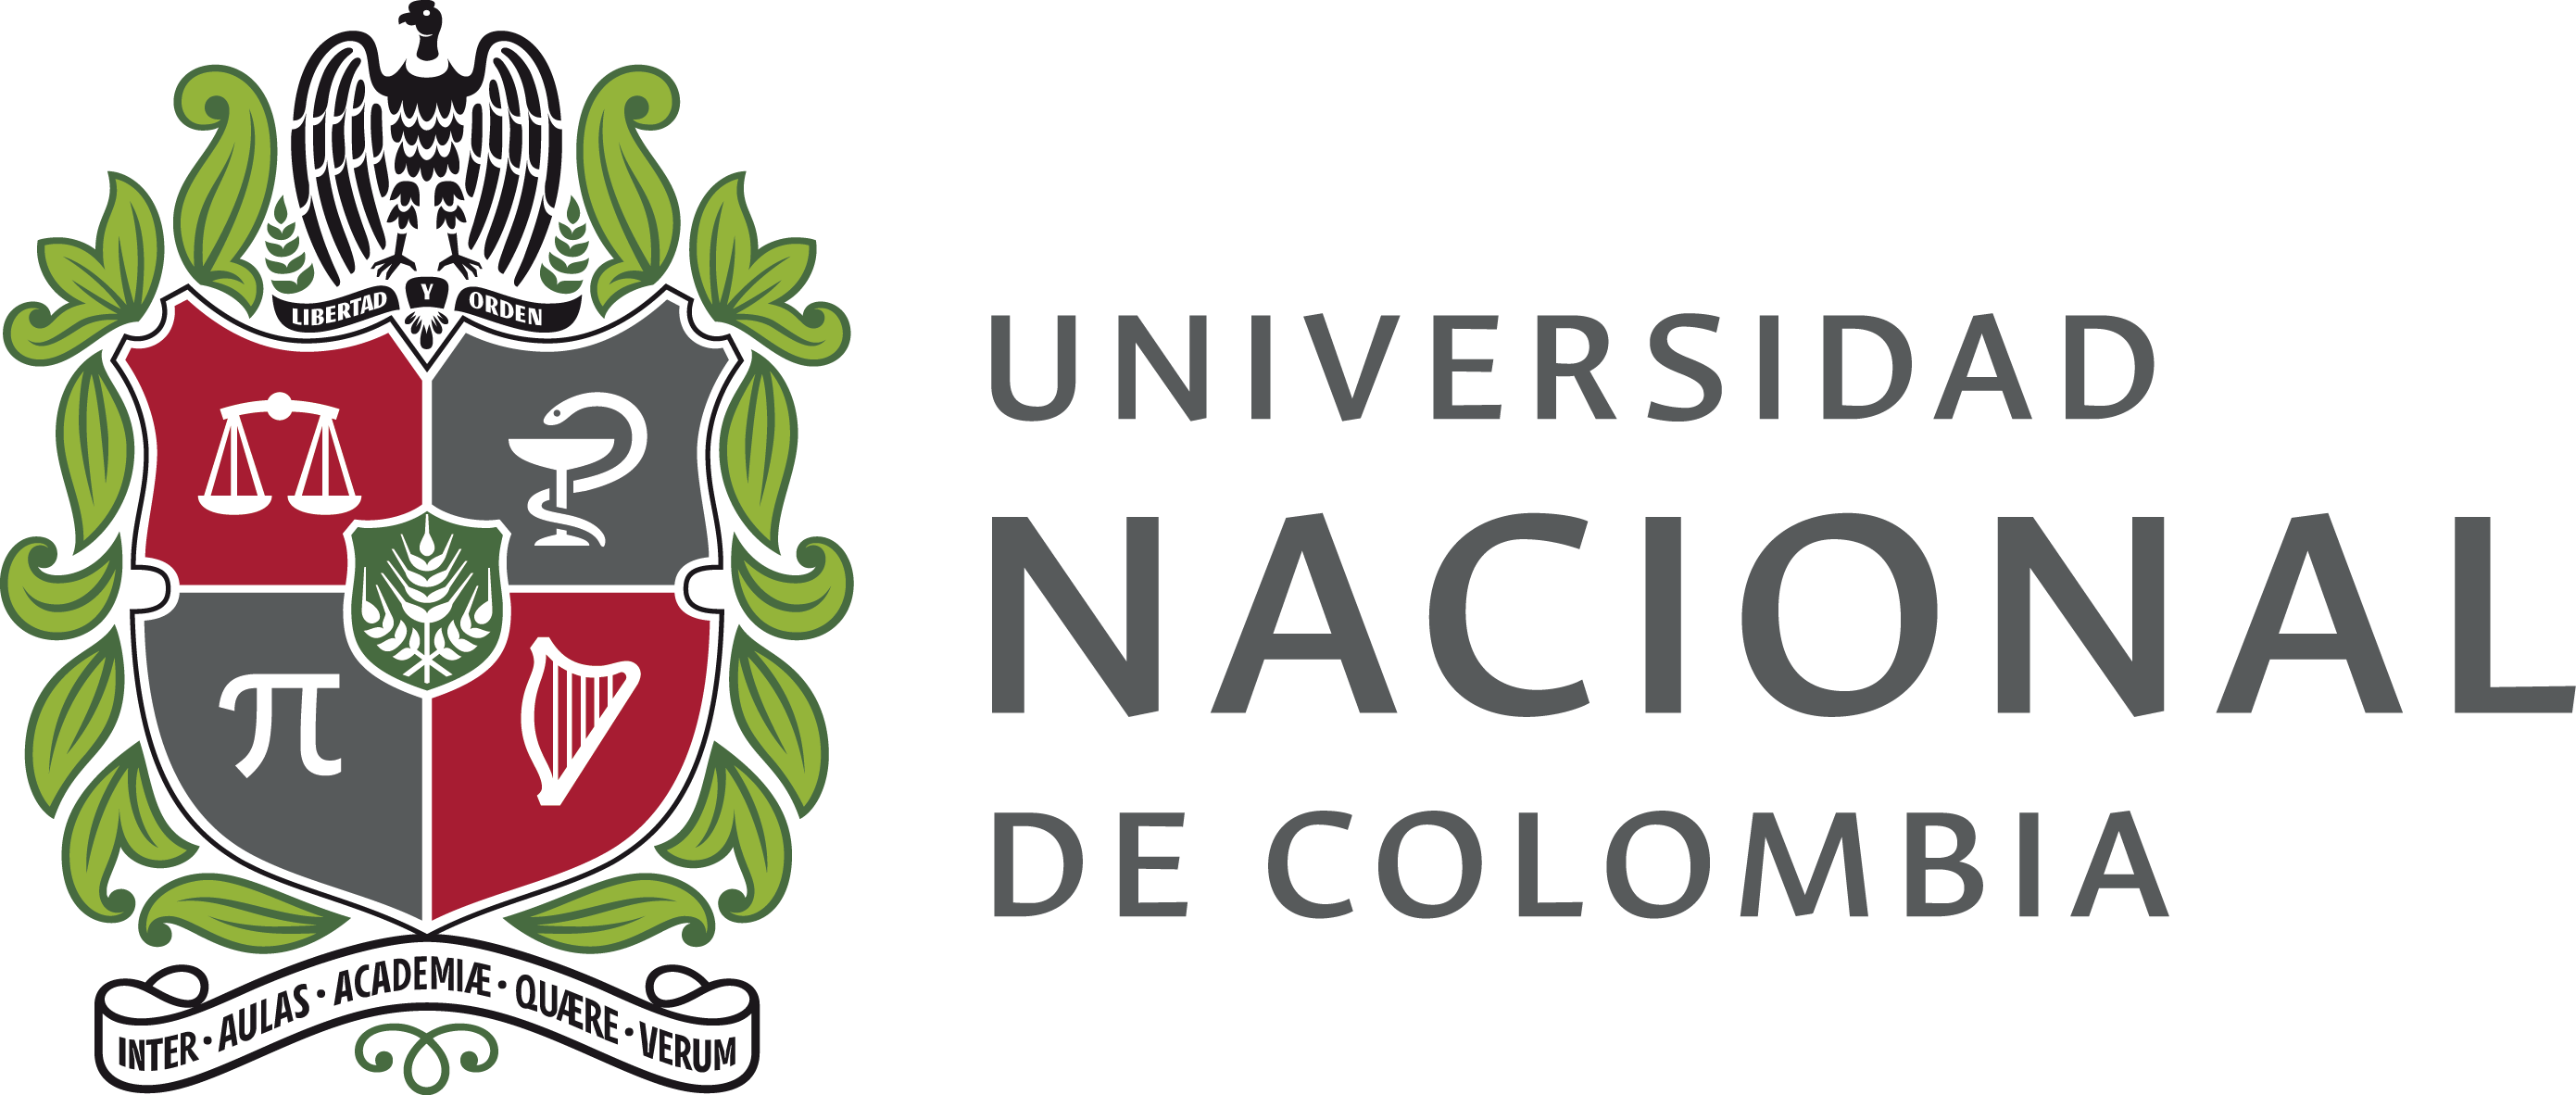
### **Universidad Nacional de Colombia sede Manizales**
#### Facultad de ingeniería y arquitectura
#### Departamento de ingeniería eléctrica, electrónica y computación
#### *Procesamiento digital de imágenes*

#### Profesor: Lucas Iturriago

### Instalar bibliotecas de Python

In [5]:
%%capture
!pip install roboflow

### Importar bibliotecas de Python

In [6]:
import os
import re
import glob
import time
import random
import numpy as np
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from roboflow import Roboflow
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from keras.saving import register_keras_serializable

2025-12-02 05:39:32.826095: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764653973.019908      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764653973.072080      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

### Descargar base de datos

In [7]:
rf = Roboflow(api_key="9smAmQgaD8pNOTsDMYKR")
project = rf.workspace("roboflow-universe-projects").project("banana-ripeness-classification")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Banana-Ripeness-Classification-1 in folder:: 100%|██████████| 5639/5639 [00:00<00:00, 7351.24it/s]


### Fijar semilla

In [8]:
seed = 42

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

### Crear tf.Dataset

In [9]:
class ClassificationDataLoader:
    def __init__(self, data_dir, batch_size, image_size, partition, augment=True,
                 prefetch=tf.data.AUTOTUNE, shuffle_buffer=1000):
        """
        TensorFlow DataLoader para clasificación de imágenes.

        Args:
            data_dir: Directorio raíz con las particiones (train/val/test)
            batch_size: Tamaño del batch
            image_size: Tupla (height, width) para redimensionar imágenes
            partition: 'train', 'val' o 'test'
            augment: Si aplicar data augmentation (solo en train)
            prefetch: Número de batches a prefetch (default: AUTOTUNE)
            shuffle_buffer: Tamaño del buffer para shuffle
        """
        self.data_dir = Path(data_dir)
        self.batch_size = batch_size
        self.image_size = image_size
        self.partition = partition
        self.augment = augment and (partition.lower() == 'train')
        self.prefetch = prefetch
        self.shuffle_buffer = shuffle_buffer

        # Cargar estructura de clases
        partition_path = self.data_dir / self.partition
        self.class_folders = sorted([d for d in partition_path.iterdir() if d.is_dir()])
        self.class_to_idx = {cls.name: idx for idx, cls in enumerate(self.class_folders)}
        self.num_classes = len(self.class_folders)

        # Recolectar samples
        self.samples = []
        self.labels = []

        supported_formats = ['*.png', '*.jpg', '*.jpeg']

        for class_folder in tqdm(self.class_folders, desc="Loading dataset"):
            class_idx = self.class_to_idx[class_folder.name]
            for format_pattern in supported_formats:
                files = glob.glob(str(class_folder / format_pattern))
                for file_path in files:
                    self.samples.append(file_path)
                    self.labels.append(class_idx)

        # Ordenar alfabéticamente
        sorted_pairs = sorted(zip(self.samples, self.labels),
                            key=lambda pair: self._alphanumeric_key(pair[0]))
        self.samples, self.labels = zip(*sorted_pairs)
        self.samples = list(self.samples)
        self.labels = list(self.labels)

        self.num_samples = len(self.samples)
        print(f"Found {self.num_samples} images across {self.num_classes} classes in {partition}")

        # Guardar mapeo de clases
        if partition.lower() == 'train':
            with open('class_mapping.txt', 'w') as f:
                f.write("Class Name -> Label Index\n")
                f.write("-" * 30 + "\n")
                for class_name, idx in sorted(self.class_to_idx.items(), key=lambda x: x[1]):
                    f.write(f"{class_name} -> {idx}\n")
            print(f"Class mapping saved to class_mapping.txt")

        # Crear dataset
        self.dataset = self._build_dataset()

    @staticmethod
    def _alphanumeric_key(s):
        """Clave para ordenamiento alfanumérico natural"""
        return [int(part) if part.isdigit() else part for part in re.split(r'(\d+)', s)]

    def _load_and_preprocess_image(self, file_path, label):
        """Carga y preprocesa una imagen"""
        # Leer imagen
        img = tf.io.read_file(file_path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])

        # Redimensionar
        img = tf.image.resize(img, self.image_size)

        # Normalizar a [0, 1]
        img = tf.cast(img, tf.float32) / 255.0

        return img, label

    def _augment_image(self, image, label):
        """Aplica data augmentation"""
        # Horizontal flip
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_left_right(image)

        # Vertical flip
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_up_down(image)

        # Brightness
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_brightness(image, 0.2)

        # Contrast
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_contrast(image, 0.8, 1.2)

        # Saturation
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_saturation(image, 0.8, 1.2)

        # Gaussian noise
        if tf.random.uniform(()) > 0.7:
            noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
            image = image + noise

        # Clip values
        image = tf.clip_by_value(image, 0.0, 1.0)

        return image, label

    def _build_dataset(self):
        """Construye el pipeline de tf.data"""
        # Crear dataset desde listas
        dataset = tf.data.Dataset.from_tensor_slices((self.samples, self.labels))

        # Shuffle si es train
        if self.partition.lower() == 'train':
            dataset = dataset.shuffle(buffer_size=self.shuffle_buffer,
                                     reshuffle_each_iteration=True)

        # Cargar y preprocesar imágenes
        dataset = dataset.map(self._load_and_preprocess_image,
                             num_parallel_calls=tf.data.AUTOTUNE)

        # Aplicar augmentation si corresponde
        if self.augment:
            dataset = dataset.map(self._augment_image,
                                 num_parallel_calls=tf.data.AUTOTUNE)

        # Batch y prefetch
        dataset = dataset.batch(self.batch_size)
        dataset = dataset.prefetch(self.prefetch)

        return dataset

    def __len__(self):
        """Retorna el número de batches"""
        return (self.num_samples + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        """Permite iterar sobre el dataset"""
        return iter(self.dataset)

    def get_dataset(self):
        """Retorna el tf.data.Dataset"""
        return self.dataset

In [10]:
# Crear dataloader para entrenamiento
train_loader = ClassificationDataLoader(
    data_dir='./Banana-Ripeness-Classification-1',
    batch_size=32,
    image_size=(128, 128),
    partition='train',
    augment=True
)

# Crear dataloader para validación
val_loader = ClassificationDataLoader(
    data_dir='./Banana-Ripeness-Classification-1',
    batch_size=32,
    image_size=(128, 128),
    partition='valid',
    augment=False
)

# Crear dataloader para evaluación
test_loader = ClassificationDataLoader(
    data_dir='./Banana-Ripeness-Classification-1',
    batch_size=1,
    image_size=(128, 128),
    partition='test',
    augment=False
)

Loading dataset: 100%|██████████| 6/6 [00:00<00:00, 248.37it/s]


Found 3931 images across 6 classes in train
Class mapping saved to class_mapping.txt


I0000 00:00:1764653995.273424      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
Loading dataset: 100%|██████████| 6/6 [00:00<00:00, 817.92it/s]


Found 1123 images across 6 classes in valid


Loading dataset: 100%|██████████| 6/6 [00:00<00:00, 1311.68it/s]

Found 562 images across 6 classes in test


### Crear y definir modelo

In [11]:
def residual_block(x, filters, stride=1, name=None):
    shortcut = x

    # Rama principal
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False, name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.ReLU(name=f"{name}_relu1")(x)

    x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)

    # Proyección si cambia dimensión
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False, name=f"{name}_proj_conv")(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_proj_bn")(shortcut)

    # Suma + activación
    x = layers.Add(name=f"{name}_add")([x, shortcut])
    x = layers.ReLU(name=f"{name}_out")(x)

    return x

# Modelo funcional 
def create_classification_model(
        num_classes,
        input_shape=(224, 224, 3),
        dropout_rate=0.3,
        learning_rate=1e-3
    ):

    inputs = keras.Input(shape=input_shape)

    # Stem
    x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False, name="stem_conv")(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.ReLU(name="stem_relu")(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same', name="stem_pool")(x)

    # Bloques residuales
    x = residual_block(x, 64, stride=1, name="block1_1")
    x = residual_block(x, 64, stride=1, name="block1_2")

    x = residual_block(x, 128, stride=2, name="block2_1")
    x = residual_block(x, 128, stride=1, name="block2_2")

    x = residual_block(x, 256, stride=2, name="block3_1")
    x = residual_block(x, 256, stride=1, name="block3_2")

    x = residual_block(x, 512, stride=2, name="block4_1")
    x = residual_block(x, 512, stride=1, name="block4_2")

    # Clasificador
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    x = layers.Dense(num_classes, name="fc")(x)
    outputs = layers.Softmax(name="softmax")(x)

    # Modelo final
    model = keras.Model(inputs, outputs, name="ResNetCustom")

    return model

In [12]:
model = create_classification_model(
        num_classes=6,
        input_shape=(128, 128,3),
        dropout_rate=0.1)

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5_accuracy')
    ]
)

In [14]:
model.summary(expand_nested=True)

Model: "ResNetCustom"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 32, 32,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv1      │ (None, 32, 32,    │     36,864 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn1        │ (None, 32, 32,    │        256 │ block1_1_conv1[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu1      │ (None, 32, 32,    │          0 │ block1_1_bn1[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv2      │ (None, 32, 32,    │     36,864 │ block1_1_relu1[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn2        │ (None, 32, 32,    │        256 │ block1_1_conv2[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_add (Add)  │ (None, 32, 32,    │          0 │ block1_1_bn2[0][… │
│                     │ 64)               │            │ stem_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_out (ReLU) │ (None, 32, 32,    │          0 │ block1_1_add[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv1      │ (None, 32, 32,    │     36,864 │ block1_1_out[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn1        │ (None, 32, 32,    │        256 │ block1_2_conv1[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_relu1      │ (None, 32, 32,    │          0 │ block1_2_bn1[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv2      │ (None, 32, 32,    │     36,864 │ block1_2_relu1[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn2        │ (None, 32, 32,    │        256 │ block1_2_conv2[0

 Total params: 11,189,190 (42.68 MB)

 Trainable params: 11,179,590 (42.65 MB)

 Non-trainable params: 9,600 (37.50 KB)

### Entrenamiento del modelo

In [15]:
history = model.fit(
    train_loader.get_dataset(),
    validation_data=val_loader.get_dataset(),
    epochs=50,
    callbacks=[
                keras.callbacks.ModelCheckpoint(
                    'best_model.keras',
                    monitor='val_accuracy',
                    save_best_only=True,
                    mode='max',
                    verbose=1
                ),
                keras.callbacks.EarlyStopping(
                    monitor='val_loss',
                    patience=10,
                    restore_best_weights=True,
                    verbose=1
                ),
                keras.callbacks.ReduceLROnPlateau( # ReduceLROnPlateau reduce el LR cuando la val_loss se estanca
                    monitor='val_loss',
                    factor=0.5,       # Reduce LR a la mitad
                    patience=3,       # Espera 5 epochs sin mejora
                    min_lr=1e-6,      # Nunca baja más de 1e-6
                    verbose=1
                )])

Epoch 1/50


I0000 00:00:1764654096.840047     130 service.cc:148] XLA service 0x7a26040047e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764654096.841065     130 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764654098.373352     130 cuda_dnn.cc:529] Loaded cuDNN version 90300


  4/123 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.3776 - loss: 2.6985 - top5_accuracy: 0.9193 

I0000 00:00:1764654106.598507     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7321 - loss: 1.0489 - top5_accuracy: 0.9792
Epoch 1: val_accuracy improved from -inf to 0.37756, saving model to best_model.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 37s 141ms/step - accuracy: 0.7320 - loss: 1.0478 - top5_accuracy: 0.9793 - val_accuracy: 0.3776 - val_loss: 2.7637 - val_top5_accuracy: 0.8878 - learning_rate: 0.0010
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6967 - loss: 1.0574 - top5_accuracy: 0.9905
Epoch 2: val_accuracy did not improve from 0.37756
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.6970 - loss: 1.0566 - top5_accuracy: 0.9905 - val_accuracy: 0.1861 - val_loss: 8.5533 - val_top5_accuracy: 0.7961 - learning_rate: 0.0010
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7182 - loss: 0.9101 - top5_accuracy: 0.9963
Epoch 3: val_accuracy improved from 0.37756 to 0.46483, saving model to best_model.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.7184 

### Evolución del entrenamiento

In [16]:
def plot_detailed_history(history, save_path='detailed_history.png'):
    """
    Grafica el historial con más detalle (incluye top-5 accuracy si está disponible)

    Args:
        history: Objeto History retornado por model.fit()
        save_path: Ruta donde guardar la imagen
    """
    # Verificar qué métricas están disponibles
    available_metrics = list(history.history.keys())
    has_top5 = 'top5_accuracy' in available_metrics

    # Determinar número de subplots
    n_plots = 3 if has_top5 else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))

    if n_plots == 2:
        ax1, ax2 = axes
    else:
        ax1, ax2, ax3 = axes

    epochs = range(1, len(history.history['loss']) + 1)

    # Plot 1: Loss
    ax1.plot(epochs, history.history['loss'], 'b-o', label='Train', linewidth=2, markersize=4)
    ax1.plot(epochs, history.history['val_loss'], 'r-s', label='Val', linewidth=2, markersize=4)
    ax1.set_title('Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Accuracy
    ax2.plot(epochs, history.history['accuracy'], 'b-o', label='Train', linewidth=2, markersize=4)
    ax2.plot(epochs, history.history['val_accuracy'], 'r-s', label='Val', linewidth=2, markersize=4)
    ax2.set_title('Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Top-5 Accuracy (si está disponible)
    if has_top5:
        ax3.plot(epochs, history.history['top5_accuracy'], 'b-o', label='Train', linewidth=2, markersize=4)
        ax3.plot(epochs, history.history['val_top5_accuracy'], 'r-s', label='Val', linewidth=2, markersize=4)
        ax3.set_title('Top-5 Accuracy', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Epoch', fontsize=12)
        ax3.set_ylabel('Top-5 Accuracy', fontsize=12)
        ax3.legend(fontsize=10)
        ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Detailed history plot saved to {save_path}")
    plt.show()

Detailed history plot saved to detailed_history.png


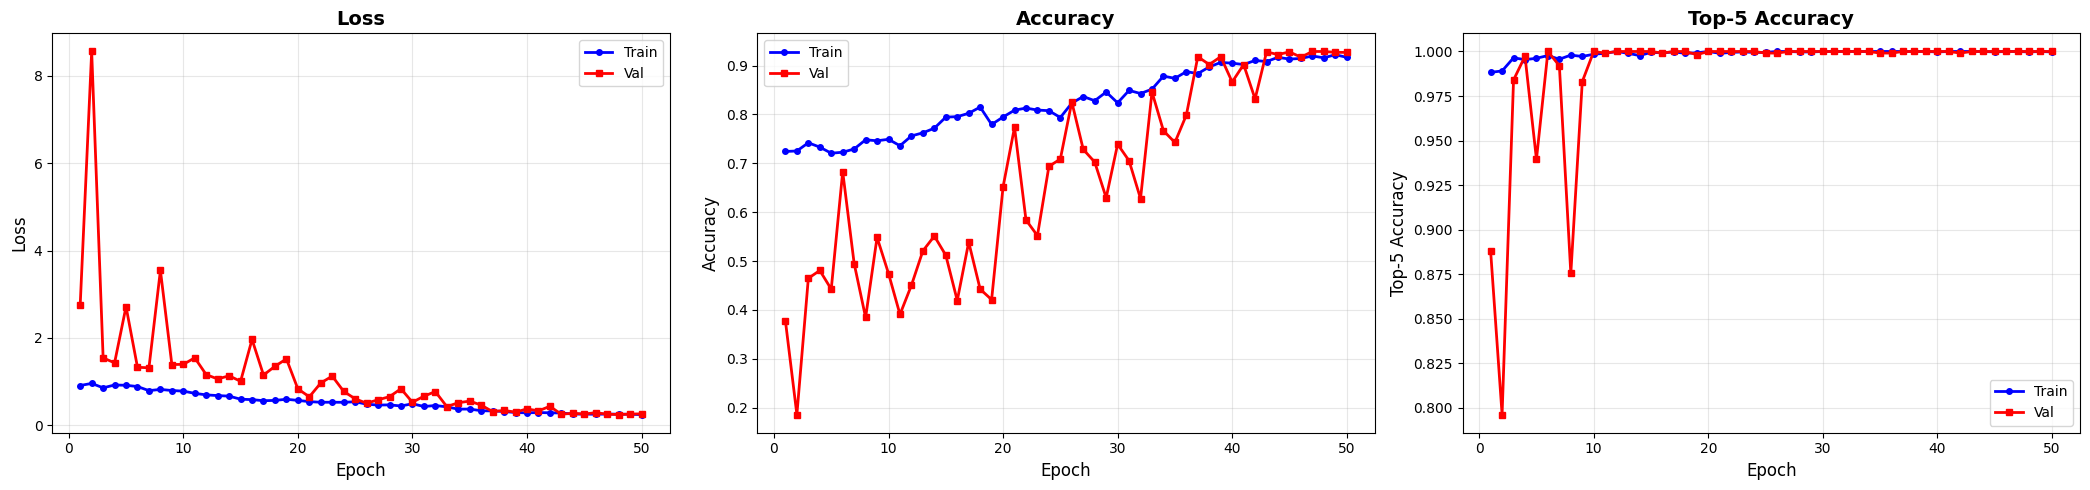

In [17]:
# Graficar historial detallado (incluye top-5 si está disponible)
plot_detailed_history(history)

### Convertir modelo a LiteRT 
(en este caso cuantización dinámica, pero puede ser otra)

In [22]:
# Cargar el modelo entrenado
model = tf.keras.models.load_model("best_model.keras")

# Convertidor LiteRT
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Activar cuantización dinámica
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convertir
litert_model = converter.convert()

# Guardar archivo .tflite
with open("model_dynamic_quant.tflite", "wb") as f:
    f.write(litert_model)

INFO:tensorflow:Assets written to: /tmp/tmpg6svpyzz/assets


INFO:tensorflow:Assets written to: /tmp/tmpg6svpyzz/assets


Saved artifact at '/tmp/tmpg6svpyzz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134304060211664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134304060224912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134304060224336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134304060225872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134304060225104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134304060224144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134304060224528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134304060226448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134304060222032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134304060223376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134304060225296

W0000 00:00:1764654471.740930      47 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1764654471.740986      47 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


### Comparación de modelos

In [23]:
# Cargar modelos
model_tf = tf.keras.models.load_model("best_model.keras")

interpreter = tf.lite.Interpreter(model_path="model_dynamic_quant.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [24]:
# Función para inferencia LiteRT
def litert_predict(interpreter, input_data):
    # Set input
    interpreter.set_tensor(input_details[0]["index"], input_data)
    interpreter.invoke()
    # Get output
    output = interpreter.get_tensor(output_details[0]["index"])
    return output

In [25]:
# Evaluar accuracy TF y LiteRT
correct_tf = 0
correct_litert = 0
total = 0

start_tf = time.time()
for images, labels in test_loader:
    preds = model_tf.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)
    correct_tf += np.sum(preds == labels.numpy())
    total += labels.shape[0]
end_tf = time.time()

# Accuracy TensorFlow
accuracy_tf = correct_tf / total


# ----- LiteRT -----
start_litert = time.time()
for images, labels in test_loader:
    images_np = images.numpy()

    for i in range(images_np.shape[0]):
        inp = images_np[i:i+1].astype(np.float32)

        pred = litert_predict(interpreter, inp)
        pred = np.argmax(pred, axis=1)

        if pred[0] == labels[i].numpy():
            correct_litert += 1

end_litert = time.time()

# Accuracy LiteRT
accuracy_litert = correct_litert / total

In [26]:
# Tiempos de inferencia
tf_inference_time = (end_tf - start_tf) / total
litert_inference_time = (end_litert - start_litert) / total

In [27]:
# Tamaño de los modelos
size_tf = os.path.getsize("best_model.keras") / (1024 * 1024)
size_litert = os.path.getsize("model_dynamic_quant.tflite") / (1024 * 1024)

In [28]:
# Resultados
print("======= RESULTADOS =======")
print(f"Accuracy TensorFlow:      {accuracy_tf:.4f}")
print(f"Accuracy LiteRT:          {accuracy_litert:.4f}")
print()
print(f"Tiempo por inferencia TF:     {tf_inference_time*1000:.3f} ms")
print(f"Tiempo por inferencia LiteRT: {litert_inference_time*1000:.3f} ms")
print()
print(f"Peso modelo TensorFlow:   {size_tf:.2f} MB")
print(f"Peso modelo LiteRT:       {size_litert:.2f} MB")
print("==========================")

======= RESULTADOS =======
Accuracy TensorFlow:      0.9270
Accuracy LiteRT:          0.9270

Tiempo por inferencia TF:     77.584 ms
Tiempo por inferencia LiteRT: 21.412 ms

Peso modelo TensorFlow:   128.26 MB
Peso modelo LiteRT:       10.74 MB
